Segment z klasami Down Up, zostal znaleziony na jednym z repo na GitHubie, sam model, jego featury to moja rola

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import cv2
import random
import matplotlib.pyplot as plt
from PIL import Image
import torch

from torchvision import transforms
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as f
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import os
import shutil
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from PIL import Image
import random
import json
from google.colab import files
SEED = 900729
dir_path = './data'
train_path = './data/Training'
test_path = './data/Testing'
uploaded=files.upload()

Saving kaggle.json to kaggle.json


In [ ]:
pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 104.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44284 sha256=1a0f214575be11aedf8ced09edd7364d0f904c4306b9783a1030be45f33c719a
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [ ]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

In [ ]:
!ls
with open("kaggle.json") as f:
    kaggle_creds = json.load(f)

username = kaggle_creds["username"]
key = kaggle_creds["key"]

os.environ['KAGGLE_USERNAME'] = username
os.environ['KAGGLE_KEY'] = key

kaggle.json  sample_data


In [ ]:
from kaggle.api.kaggle_api_extended import KaggleApi

api = KaggleApi()
api.authenticate()


In [ ]:
api.dataset_download_files("masoudnickparvar/brain-tumor-mri-dataset", path="./data", unzip=True)


Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset


In [ ]:
def train_df(tr_path):
    classes, class_paths = zip(*[(label, os.path.join(tr_path, label, image))
                                 for label in os.listdir(tr_path) if os.path.isdir(os.path.join(tr_path, label))
                                 for image in os.listdir(os.path.join(tr_path, label))])

    tr_df = pd.DataFrame({'Class Path': class_paths, 'Class': classes})
    return tr_df

In [ ]:
def test_df(ts_path):
    classes, class_paths = zip(*[(label, os.path.join(ts_path, label, image))
                                 for label in os.listdir(ts_path) if os.path.isdir(os.path.join(ts_path, label))
                                 for image in os.listdir(os.path.join(ts_path, label))])

    ts_df = pd.DataFrame({'Class Path': class_paths, 'Class': classes})
    return ts_df

In [ ]:
tr_orginal_df = train_df(train_path)
ts_orginal_df = test_df(test_path)
ts_orginal_df


,Class Path,Class
0,./data/Testing/meningioma/Te-me_0156.jpg,meningioma
1,./data/Testing/meningioma/Te-me_0026.jpg,meningioma
2,./data/Testing/meningioma/Te-me_0094.jpg,meningioma
3,./data/Testing/meningioma/Te-me_0075.jpg,meningioma
4,./data/Testing/meningioma/Te-me_0167.jpg,meningioma
...,...,...
1306,./data/Testing/glioma/Te-gl_0108.jpg,glioma
1307,./data/Testing/glioma/Te-gl_0024.jpg,glioma
1308,./data/Testing/glioma/Te-glTr_0007.jpg,glioma
1309,./data/Testing/glioma/Te-gl_0235.jpg,glioma


In [ ]:
tr_orginal_df

,Class Path,Class
0,./data/Training/meningioma/Tr-me_0322.jpg,meningioma
1,./data/Training/meningioma/Tr-me_1304.jpg,meningioma
2,./data/Training/meningioma/Tr-me_0840.jpg,meningioma
3,./data/Training/meningioma/Tr-me_1295.jpg,meningioma
4,./data/Training/meningioma/Tr-me_0451.jpg,meningioma
...,...,...
5707,./data/Training/glioma/Tr-gl_0171.jpg,glioma
5708,./data/Training/glioma/Tr-gl_1118.jpg,glioma
5709,./data/Training/glioma/Tr-gl_0329.jpg,glioma
5710,./data/Training/glioma/Tr-gl_0592.jpg,glioma


In [ ]:
val_df, tr_df = train_test_split(tr_orginal_df, train_size=0.25, random_state=SEED, stratify=tr_orginal_df['Class'])

validation_path = './data/Validation'
Path(validation_path).mkdir(exist_ok=True)

classes = ['glioma', 'meningioma', 'notumor', 'pituitary']
for class_name in classes:
    class_validation_path = Path(validation_path) / class_name
    class_validation_path.mkdir(exist_ok=True)

errors = []

for idx, row in val_df.iterrows():
    try:
        source_path = Path(row['Class Path'])

        filename = source_path.name
        class_name = row['Class']
        destination_path = Path(validation_path) / class_name / filename

        shutil.move(str(source_path), str(destination_path))

    except Exception as e:
        errors.append({
            'file': row['Class Path'],
            'class': row['Class'],
            'error': str(e)
        })


if errors:
    print(f"Errors: {len(errors)}")
    for error in errors:
        print(f"  - {error['class']}: {Path(error['file']).name} - {error['error']}")

val_df_updated = val_df.copy()
val_df_updated['Class Path'] = val_df_updated.apply(
    lambda row: str(Path(validation_path) / row['Class'] / Path(row['Class Path']).name),
    axis=1
)

tr_df_updated = train_df(train_path)

val_df = val_df_updated
tr_df = tr_df_updated

val_df

,Class Path,Class
312,data/Validation/meningioma/Tr-me_0680.jpg,meningioma
2060,data/Validation/notumor/Tr-no_1069.jpg,notumor
5526,data/Validation/glioma/Tr-glTr_0007.jpg,glioma
5546,data/Validation/glioma/Tr-gl_0105.jpg,glioma
4935,data/Validation/glioma/Tr-gl_1046.jpg,glioma
...,...,...
3281,data/Validation/pituitary/Tr-pi_0379.jpg,pituitary
847,data/Validation/meningioma/Tr-me_1066.jpg,meningioma
86,data/Validation/meningioma/Tr-me_0122.jpg,meningioma
1220,data/Validation/meningioma/Tr-me_1251.jpg,meningioma


In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader


transform_tr = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomRotation(degrees=20),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
     transforms.Normalize(mean=[0.5],
                         std=[0.5])
])
transform_ts=transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
     transforms.Normalize(mean=[0.5],
                         std=[0.5])
])
transform_val =transforms.Compose([
    transforms.Resize((256,256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5],
                         std=[0.5])
])

train_dataset = datasets.ImageFolder(root=train_path, transform=transform_tr)
test_dataset  = datasets.ImageFolder(root=test_path, transform=transform_ts)
val_dataset   = datasets.ImageFolder(root=validation_path, transform=transform_val)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
print(train_dataset.classes)

['glioma', 'meningioma', 'notumor', 'pituitary']


In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class DoubleConv(nn.Module):
    """(convolution => [BN] => ReLU) * 2"""

    def __init__(self, in_channels, out_channels, mid_channels=None):
        super().__init__()
        if not mid_channels:
            mid_channels = out_channels
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, mid_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(mid_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(mid_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)

class Down(nn.Module):
    """Downscaling with maxpool then double conv"""

    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels)
        )

    def forward(self, x):
        return self.maxpool_conv(x)


class Up(nn.Module):
    """Upscaling then double conv"""

    def __init__(self, in_channels, out_channels, bilinear=True):
        super().__init__()

        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
            self.conv = DoubleConv(in_channels, out_channels, in_channels // 2)
        else:
            self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)
            self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):
        x1 = self.up(x1)
        # input is CHW
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]

        x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2,
                        diffY // 2, diffY - diffY // 2])

        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)


class OutConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(OutConv, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x):
        return self.conv(x)

In [ ]:
class UNet(nn.Module):
    def __init__(self, n_channels, n_classes, bilinear=False):
        super(UNet, self).__init__()
        self.n_channels = n_channels
        self.n_classes = n_classes
        self.bilinear = bilinear

        self.inc = (DoubleConv(n_channels, 64))
        self.down1 = (Down(64, 128))
        self.down2 = (Down(128, 256))
        self.down3 = (Down(256, 512))

        factor = 2 if bilinear else 1

        self.down4 = (Down(512, 1024 // factor))
        self.down5 = (Down(1024, 2048 // factor))
        self.up0=  (Up(2048, 1024 // factor, bilinear))
        self.up1 = (Up(1024, 512 // factor, bilinear))
        self.up2 = (Up(512, 256 // factor, bilinear))
        self.up3 = (Up(256, 128 // factor, bilinear))
        self.up4 = (Up(128, 64 // factor, bilinear))
        self.outc = (OutConv(64, n_classes))

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(n_classes, n_classes)


    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)
        x6 = self.down5(x5)
        x = self.up0(x6, x5)
        x = self.up1(x, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        logits = self.outc(x)

        x = self.avgpool(logits)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x


    def use_checkpointing(self):
        self.inc = torch.utils.checkpoint(self.inc)
        self.down1 = torch.utils.checkpoint(self.down1)
        self.down2 = torch.utils.checkpoint(self.down2)
        self.down3 = torch.utils.checkpoint(self.down3)
        self.down4 = torch.utils.checkpoint(self.down4)
        self.down5 = torch.utils.checkpoint(self.down5)
        self.up0 = torch.utils.checkpoint(self.up0)
        self.up1 = torch.utils.checkpoint(self.up1)
        self.up2 = torch.utils.checkpoint(self.up2)
        self.up3 = torch.utils.checkpoint(self.up3)
        self.up4 = torch.utils.checkpoint(self.up4)

        self.outc = torch.utils.checkpoint(self.outc)

In [ ]:
import torch

import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNet(n_channels=3, n_classes=4).to(device)
best_loss = float('inf')
patience = 5
counter = 0
from sklearn.utils.class_weight import compute_class_weight

weights = compute_class_weight('balanced', classes=np.unique(train_dataset.targets), y=train_dataset.targets)
weights = torch.tensor(weights, dtype=torch.float32).to(device)
criterion = torch.nn.CrossEntropyLoss(weight=weights)

optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler= optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10,eta_min=1e-6)
for epoch in range(10):
    model.train()
    running_loss = 0.0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)



        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader):.4f}")

Epoch 1, Loss: 1.0731
Epoch 2, Loss: 0.9143
Epoch 3, Loss: 0.8232
Epoch 4, Loss: 0.7345
Epoch 5, Loss: 0.6863
Epoch 6, Loss: 0.6291
Epoch 7, Loss: 0.5747
Epoch 8, Loss: 0.5361
Epoch 9, Loss: 0.5060
Epoch 10, Loss: 0.4594


In [ ]:
model.eval()
val_loss = 0.0
with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

val_loss /= len(val_loader)
if val_loss < best_loss:
    best_loss = val_loss
    counter = 0
    torch.save(model.state_dict(), 'best_model.pth')



Test Loss: 0.7601
Test Accuracy: 72.39%

Classification Report:
              precision    recall  f1-score   support

      glioma       0.98      0.69      0.81       300
  meningioma       0.60      0.27      0.37       306
     notumor       0.91      0.89      0.90       405
   pituitary       0.53      1.00      0.69       300

    accuracy                           0.72      1311
   macro avg       0.75      0.71      0.69      1311
weighted avg       0.77      0.72      0.71      1311


Confusion Matrix:


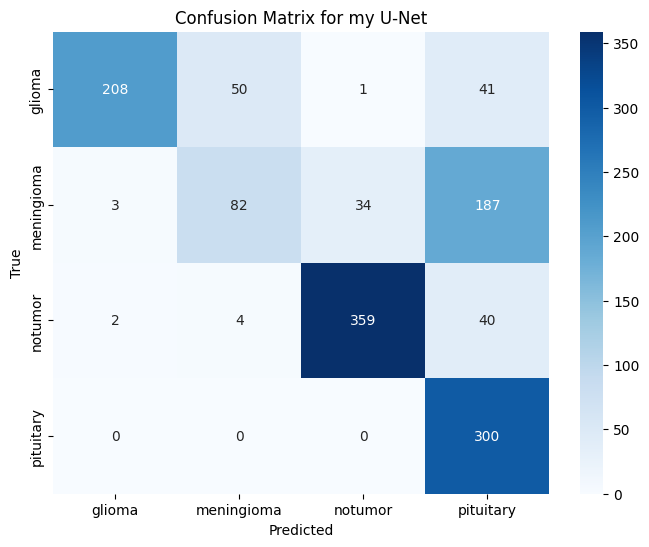

In [ ]:
model.load_state_dict(torch.load('best_model.pth'))

model.eval()
test_loss = 0.0
correct = 0
total = 0
all_labels = []
all_predictions = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        test_loss += loss.item()

        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

test_loss /= len(test_loader)
accuracy = 100 * correct / total

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {accuracy:.2f}%")


print("\nClassification Report:")
print(classification_report(all_labels, all_predictions, target_names=test_dataset.classes))

print("\nConfusion Matrix:")
cm = confusion_matrix(all_labels, all_predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=test_dataset.classes, yticklabels=test_dataset.classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for my U-Net')
plt.show()

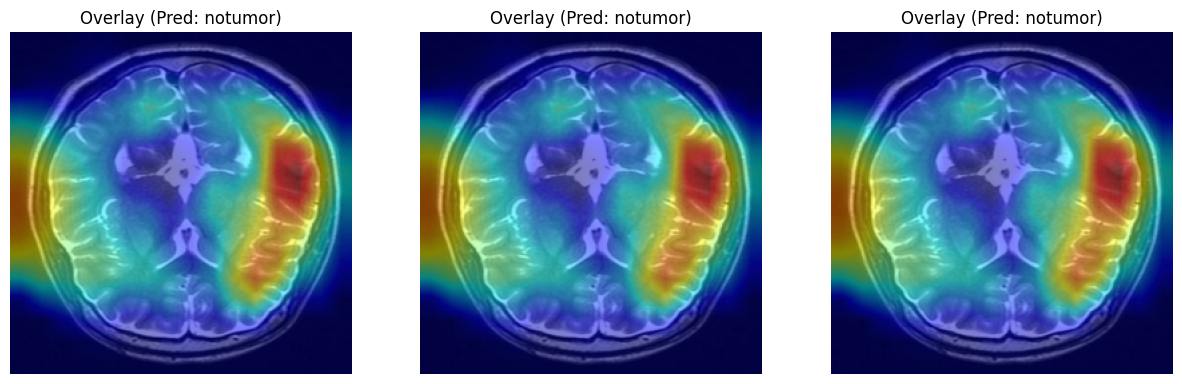

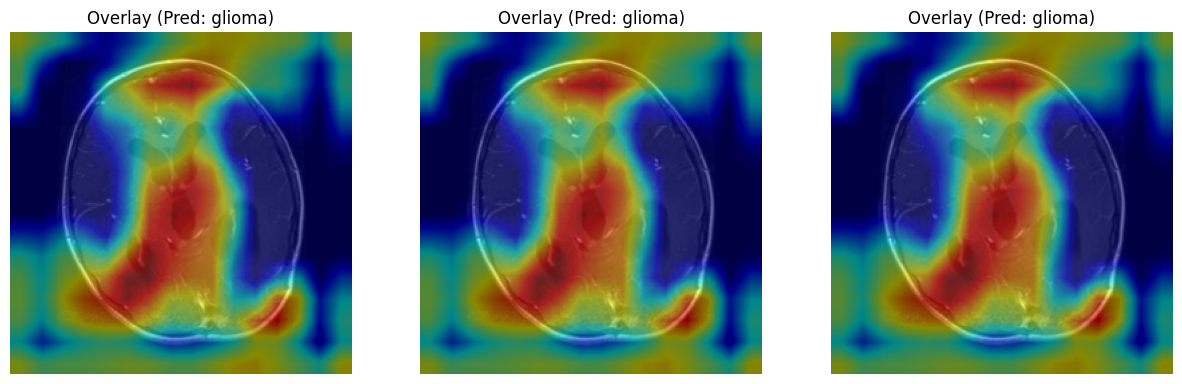

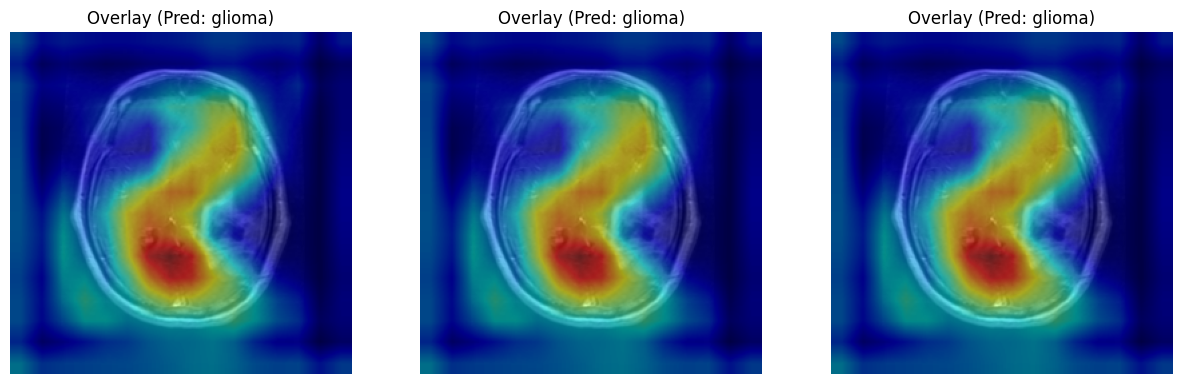

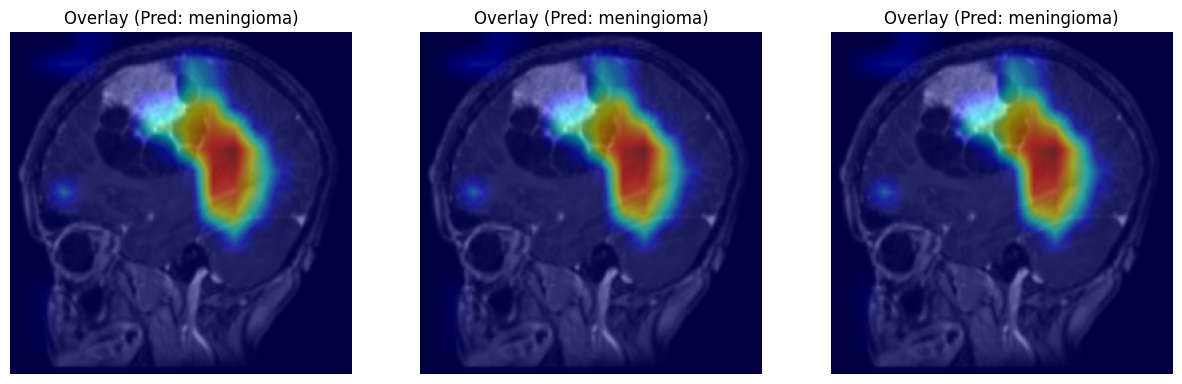

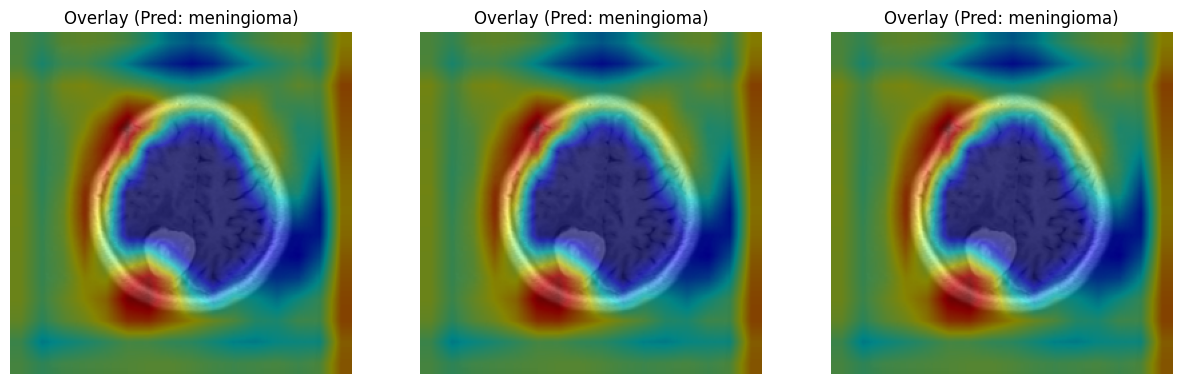

In [ ]:
model = UNet(n_channels=3, n_classes=4)
model.load_state_dict(torch.load('best_model.pth'))
model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)


target_layers = [model.down4]



cam = GradCAM(model=model, target_layers=target_layers)



data_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),

    transforms.Normalize(mean=[0.5], std=[0.5])
])


def generate_and_show_gradcam(image_path, model, cam, transform, class_names):

    img = Image.open(image_path).convert('RGB')
    img_tensor = transform(img).unsqueeze(0).to(device)


    with torch.no_grad():
        outputs = model(img_tensor)
        _, predicted_class = torch.max(outputs, 1)
        predicted_class_idx = predicted_class.item()


    img_np = img_tensor.squeeze(0).cpu().permute(1, 2, 0).numpy()

    mean = np.array([0.5])
    std = np.array([0.5])
    img_np = std * img_np + mean
    img_np = np.clip(img_np, 0, 1)



    targets = [ClassifierOutputTarget(predicted_class_idx)]



    grayscale_cam = cam(input_tensor=img_tensor, targets=targets)
    grayscale_cam = grayscale_cam[0, :]


    visualization = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)



    fig, axes = plt.subplots(1,3, figsize=(15, 5))
    axes[0].imshow(visualization)
    axes[0].set_title(f'Overlay (Pred: {class_names[predicted_class_idx]})')
    axes[0].axis('off')

    axes[1].imshow(visualization)
    axes[1].set_title(f'Overlay (Pred: {class_names[predicted_class_idx]})')
    axes[1].axis('off')

    axes[2].imshow(visualization)
    axes[2].set_title(f'Overlay (Pred: {class_names[predicted_class_idx]})')
    axes[2].axis('off')
    plt.show()


class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']


sample_image_paths = ts_orginal_df['Class Path'].sample(5, random_state=SEED).tolist()

for image_path in sample_image_paths:
    generate_and_show_gradcam(image_path, model, cam, data_transform, class_names)